<a href="https://colab.research.google.com/github/gabriela0402/ai-interview-evaluator/blob/main/notebooks/02_consistencia_avaliacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento de consistência das avaliações

## Objetivo

Investigar se o modelo de linguagem produz avaliações semelhantes quando recebe
exatamente a mesma pergunta, competência e resposta mais de uma vez.

A consistência será analisada comparando as notas geradas em diferentes execuções.

> Este experimento é educacional. A IA não deve ser usada sozinha para tomar
> decisões reais de contratação.


In [1]:
%pip install -q openai pandas pydantic python-dotenv scikit-learn matplotlib seaborn


In [2]:
import sys
import time
import re
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(f"Python: {sys.version.split()[0]}")
print(f"Pandas: {pd.__version__}")
print("Ambiente configurado.")


Python: 3.13.15
Pandas: 2.2.3
Ambiente configurado.


In [3]:
url_dataset = (
    "https://raw.githubusercontent.com/"
    "gabriela0402/ai-interview-evaluator/"
    "main/data/sample/entrevista_dataset_inicial.jsonl"
 )

dataset = pd.read_json(url_dataset, lines=True)

print(f"Dataset carregado: {len(dataset)} respostas")
display(dataset.head())


Dataset carregado: 9 respostas


,id,pergunta,competencia,resposta,nivel_esperado
0,resp_001,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,"Durante um trabalho em grupo, percebemos que o...",5
1,resp_002,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,Uma vez tive um problema em um trabalho e tent...,3
2,resp_003,Conte sobre uma situação em que você precisou ...,resolucao_de_problemas,"Já tive problemas antes, mas normalmente outra...",1
3,resp_004,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,"Em um projeto da faculdade, cada pessoa ficou ...",5
4,resp_005,Fale sobre uma situação em que você trabalhou ...,trabalho_em_equipe,Já fiz trabalhos em grupo. Cada pessoa fez sua...,3


In [4]:
url_avaliador = (
    "https://raw.githubusercontent.com/"
    "gabriela0402/ai-interview-evaluator/"
    "main/src/avaliador.py"
 )

codigo_avaliador = requests.get(
    url_avaliador + "?versao=1"
).text

with open("avaliador.py", "w", encoding="utf-8") as arquivo:
    arquivo.write(codigo_avaliador)

print("Arquivo avaliador.py carregado.")


Arquivo avaliador.py carregado.


In [6]:
resposta_teste = dataset.iloc[0]

print("ID:", resposta_teste["id"])
print("Pergunta:", resposta_teste["pergunta"])
print("Competência:", resposta_teste["competencia"])
print("Resposta:", resposta_teste["resposta"])


ID: resp_001
Pergunta: Conte sobre uma situação em que você precisou resolver um problema.
Competência: resolucao_de_problemas
Resposta: Durante um trabalho em grupo, percebemos que os dados estavam inconsistentes no dia anterior à apresentação. Eu conferi as fontes, encontrei os valores incorretos e organizei uma divisão de tarefas para corrigirmos tudo. Conseguimos finalizar a apresentação no prazo.


In [8]:
from google.colab import userdata
from openai import OpenAI

token_hf = userdata.get("HF_TOKEN")

if not token_hf:
    raise ValueError(
        "O segredo HF_TOKEN não foi encontrado nos Secrets do Colab."
    )

cliente_hf = OpenAI(
    api_key=token_hf,
    base_url="https://router.huggingface.co/v1"
 )

modelo_hf = "openai/gpt-oss-20b"

resultados_consistencia = []

for repeticao in range(quantidade_repeticoes):
    print(
        f"Executando repetição "
        f"{repeticao + 1} de {quantidade_repeticoes}..."
    )

    avaliacao = avaliar_resposta(
        resposta_teste,
        cliente_hf,
        modelo_hf
    )

    resultados_consistencia.append({
        "id": resposta_teste["id"],
        "repeticao": repeticao + 1,
        "avaliacao_modelo": avaliacao
    })

    time.sleep(2)

resultados_consistencia_df = pd.DataFrame(
    resultados_consistencia
)

display(resultados_consistencia_df)


Executando repetição 1 de 3...
Executando repetição 2 de 3...
Executando repetição 3 de 3...


,id,repeticao,avaliacao_modelo
0,resp_001,1,Relevância: 5 \nEspecificidade: 3 \nComunica...
1,resp_001,2,Relevância: 5 \nEspecificidade: 3 \nComunica...
2,resp_001,3,Relevância: 5 \nEspecificidade: 3 \nComunica...


In [9]:
print("Experimento preparado.")

print(f"Resposta selecionada: {resposta_teste['id']}")
print(f"Quantidade de repetições: {quantidade_repeticoes}")
print(f"Modelo configurado: {modelo_hf}")

print(
    "\nA execução foi planejada, mas não será realizada agora "
    "porque a cota gratuita da API foi esgotada."
)


Experimento preparado.
Resposta selecionada: resp_001
Quantidade de repetições: 3
Modelo configurado: openai/gpt-oss-20b

A execução foi planejada, mas não será realizada agora porque a cota gratuita da API foi esgotada.


In [15]:
import requests
import importlib.util

url_metricas = (
    "https://raw.githubusercontent.com/"
    "gabriela0402/ai-interview-evaluator/"
    "main/src/metricas.py"
 )

codigo_metricas = requests.get(
    url_metricas + "?versao=1"
).text

with open("metricas.py", "w", encoding="utf-8") as arquivo:
    arquivo.write(codigo_metricas)

print("Arquivo metricas.py carregado com sucesso!")


Arquivo metricas.py carregado com sucesso!


In [17]:
from metricas import extrair_avaliacao

notas_consistencia = resultados_consistencia_df[
    "avaliacao_modelo"
].apply(
    extrair_avaliacao
).apply(pd.Series)

resultados_consistencia_com_notas = pd.concat(
    [
        resultados_consistencia_df[
            ["id", "repeticao"]
        ].reset_index(drop=True),
        notas_consistencia
    ],
    axis=1
)

display(resultados_consistencia_com_notas)


,id,repeticao,nota_relevancia,nota_especificidade,nota_comunicacao,nota_reflexao,nota_resultado,nota_geral
0,resp_001,1,5.0,3.0,4.0,2.0,3.0,3.4
1,resp_001,2,5.0,3.0,4.0,2.0,3.0,3.4
2,resp_001,3,5.0,3.0,4.0,2.0,3.0,3.4


In [18]:
colunas_notas = [
    "nota_relevancia",
    "nota_especificidade",
    "nota_comunicacao",
    "nota_reflexao",
    "nota_resultado",
    "nota_geral"
]

variacao_consistencia = (
    resultados_consistencia_com_notas[
        colunas_notas
    ]
    .agg(["mean", "std", "min", "max"])
    .T
)

display(variacao_consistencia)


,mean,std,min,max
nota_relevancia,5.0,0.0,5.0,5.0
nota_especificidade,3.0,0.0,3.0,3.0
nota_comunicacao,4.0,0.0,4.0,4.0
nota_reflexao,2.0,0.0,2.0,2.0
nota_resultado,3.0,0.0,3.0,3.0
nota_geral,3.4,0.0,3.4,3.4


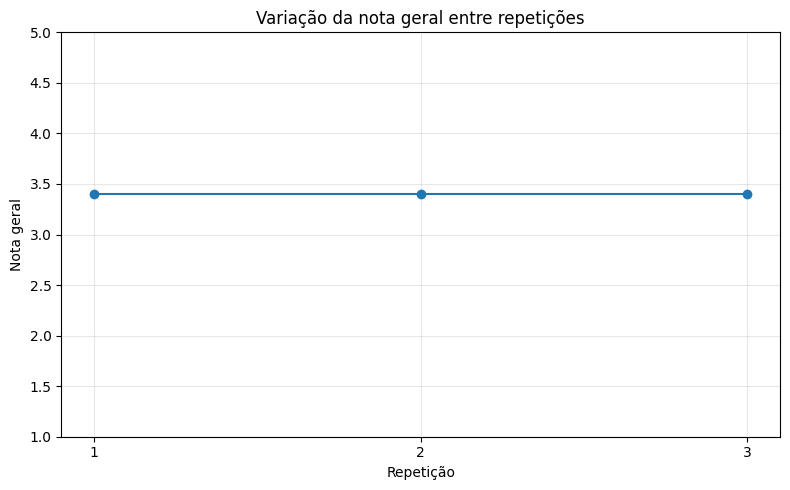

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    resultados_consistencia_com_notas["repeticao"],
    resultados_consistencia_com_notas["nota_geral"],
    marker="o"
)

plt.title("Variação da nota geral entre repetições")
plt.xlabel("Repetição")
plt.ylabel("Nota geral")
plt.xticks([1, 2, 3])
plt.ylim(1, 5)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "grafico_consistencia_nota_geral.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


In [20]:
resultados_consistencia_com_notas.to_csv(
    "resultados_consistencia.csv",
    index=False,
    encoding="utf-8-sig"
)

variacao_consistencia.to_csv(
    "resumo_consistencia.csv",
    encoding="utf-8-sig"
)

print("Tabela e resumo salvos com sucesso.")


Tabela e resumo salvos com sucesso.
